Notebook 2 — Data Cleaning & Feature Engineering

Objective:
The purpose of this notebook is to transform raw transactional retail data into enterprise-grade analytical datasets suitable for:
* machine learning
* customer analytics
* forecasting
* anomaly detection
* dashboard reporting
* executive insights

This notebook focuses on:
* cleaning data quality issues
* engineering business features
* creating customer intelligence metrics
* preparing ML-ready datasets

The resulting datasets will serve as the analytical foundation for the remainder of the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

orders = pd.read_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/Global_Superstore2.csv", encoding="latin1")


In [2]:
orders.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

---------------------------------------

Data Cleaning

1. Standardize Column Names

In [4]:
orders.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [5]:
orders.columns = ( orders.columns .str.lower()  .str.replace(" ", "_") .str.replace("-", "_"))

In [6]:
orders.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')

2. Remove Duplicates

In [7]:
orders.duplicated().sum()

np.int64(0)

In [8]:
orders = orders.drop_duplicates()

In [9]:
orders.duplicated().sum()

np.int64(0)

 3. Missing Values

In [10]:
missing_values = pd.DataFrame({ "missing_count": orders.isnull().sum(), "missing_percentage": ( orders.isnull().sum() / len(orders) ) * 100})

In [11]:
missing_values.sort_values( by="missing_percentage", ascending=False)

,missing_count,missing_percentage
postal_code,41296,80.51472
row_id,0,0.00000
region,0,0.00000
shipping_cost,0,0.00000
profit,0,0.00000
discount,0,0.00000
quantity,0,0.00000
sales,0,0.00000
product_name,0,0.00000
sub_category,0,0.00000


In [12]:
orders = orders.drop(columns=["postal_code"])

In [13]:
missing_values2 = pd.DataFrame({ "missing_count": orders.isnull().sum(), "missing_percentage": ( orders.isnull().sum() / len(orders) ) * 100})
missing_values2

,missing_count,missing_percentage
row_id,0,0.0
order_id,0,0.0
order_date,0,0.0
ship_date,0,0.0
ship_mode,0,0.0
customer_id,0,0.0
customer_name,0,0.0
segment,0,0.0
city,0,0.0
state,0,0.0


-------------------------------------------

Data Validation

1. Check Negetive Sales

In [14]:
orders[orders["sales"] < 0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority


2. Invalid Quantities

In [15]:
orders[orders["quantity"]<=0]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority


3. Discount Range

In [16]:
orders["discount"].describe()

count    51290.000000
mean         0.142908
std          0.212280
min          0.000000
25%          0.000000
50%          0.000000
75%          0.200000
max          0.850000
Name: discount, dtype: float64

In [17]:
orders[ (orders["discount"] < 0)  | (orders["discount"] > 1)]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority


------------------------------------------

Data Engineering

1. Convert Date Columns

In [18]:
orders["order_date"] = pd.to_datetime( orders["order_date"])
orders["ship_date"] = pd.to_datetime( orders["ship_date"])
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  object        
 2   order_date      51290 non-null  datetime64[ns]
 3   ship_date       51290 non-null  datetime64[ns]
 4   ship_mode       51290 non-null  object        
 5   customer_id     51290 non-null  object        
 6   customer_name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  market          51290 non-null  object        
 12  region          51290 non-null  object        
 13  product_id      51290 non-null  object        
 14  category        51290 non-null  object        
 15  su

2. Extract Date Features

In [19]:
orders["order_year"] = (orders["order_date"].dt.year)
orders["order_month"] = (orders["order_date"].dt.month)
orders["order_day"] = (orders["order_date"].dt.day)
orders["order_quarter"] = (orders["order_date"].dt.quarter)
orders["order_weekday"] = (orders["order_date"].dt.day_name())

3. Weekend Indicator

In [20]:
orders["is_weekend"] = np.where( orders["order_date"].dt.weekday >= 5, 1,0)

--------------------------------

Shipping Features

1. Shipping Duration

In [21]:
orders["shipping_days"] = ( orders["ship_date"] - orders["order_date"]).dt.days
orders["shipping_days"].describe()


count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

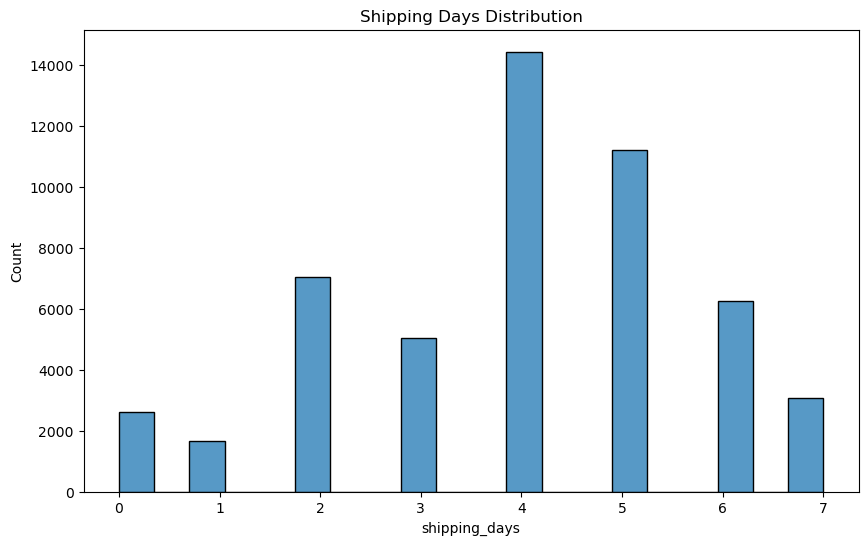

In [22]:
plt.figure(figsize=(10,6))
sns.histplot( orders["shipping_days"], bins=20)
plt.title("Shipping Days Distribution")
plt.show()

2. Shipping Performance Categories

In [23]:
orders["shipping_speed"] = pd.cut(orders["shipping_days"], bins=[0, 2, 5, 10],    labels=[ "Fast",  "Medium",   "Slow"  ])

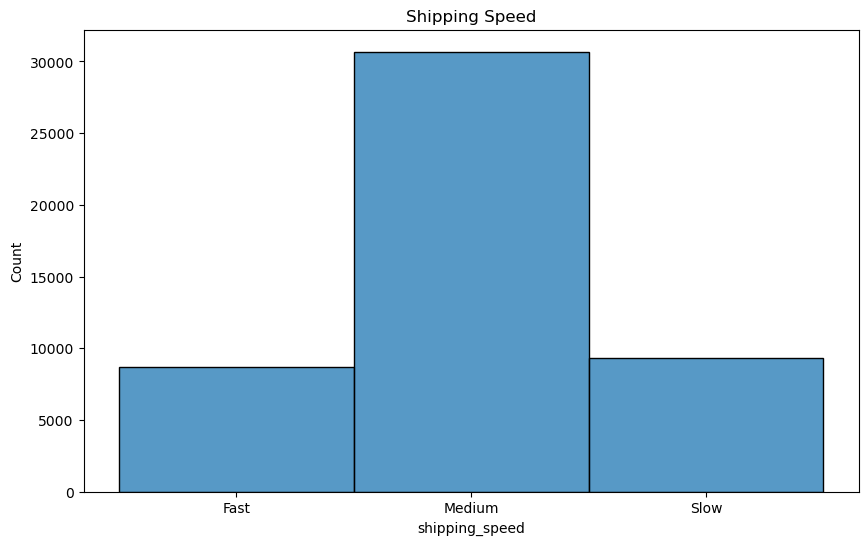

In [24]:
plt.figure(figsize=(10,6))
sns.histplot( orders["shipping_speed"], bins=20)
plt.title("Shipping Speed")
plt.show()

Insight 1 

The distribution reveals that the company relies overwhelmingly on its standard tier, with Medium shipping speed serving as the dominant operational category and capturing a massive volume of over 30,000 transactions. In comparison, the remaining two tiers show a highly balanced, symmetric distribution but at a much lower volume, with the premium Fast tier and the budget Slow tier hovering almost identically just under the 10,000 transaction mark. This distinct distribution pattern demonstrates that while specialized fast tracking and slower shipping alternatives are consistently utilized, the vast majority of consumer logistics defaults directly into the mid-tier delivery option.

______________

Profitability Features

1. Profit Margin

In [25]:
orders["profit_margin"] = (orders["profit"] / orders["sales"])
orders["profit_margin"] = (orders["profit_margin"] .replace([np.inf, -np.inf], np.nan))


2. High Discount Flag

In [26]:
orders["high_discount_flag"] = np.where( orders["discount"] >= 0.5, 1,0)

3. Loss-making Orders Flag

In [27]:
orders["loss_order_flag"] = np.where( orders["profit"] < 0,  1,0)

_____________________________

Customer Features

1. Customer Order Count

In [28]:
customer_order_count = (orders.groupby("customer_id")["order_id"] .count().reset_index())
customer_order_count.columns = [ "customer_id", "total_orders"]
orders = orders.merge(customer_order_count, on="customer_id",  how="left")

2. Customer Lifetime Value 

In [29]:
customer_clv = ( orders.groupby("customer_id")["sales"]  .sum() .reset_index())
customer_clv.columns = [ "customer_id",  "customer_lifetime_value"]
orders = orders.merge( customer_clv,  on="customer_id",  how="left")

3. Average Order Value

In [30]:
customer_avg_order = ( orders.groupby("customer_id")["sales"] .mean() .reset_index())
customer_avg_order.columns = [ "customer_id",  "avg_order_value"]
orders = orders.merge( customer_avg_order,  on="customer_id",  how="left")

_____________________________

RFM Feature Engineering

1. Latest Transaction Date

In [31]:
latest_date = orders["order_date"].max()

2. RFM Table

In [32]:
rfm = orders.groupby("customer_id").agg({ "order_date": lambda x: (latest_date - x.max() ).days,  "order_id": "count", "sales": "sum"}).reset_index()

In [33]:
rfm.columns = [  "customer_id",  "recency", "frequency", "monetary"]

In [34]:
rfm.head()

,customer_id,recency,frequency,monetary
0,AA-10315,8,42,13747.41300
1,AA-10375,6,42,5884.19500
2,AA-10480,125,38,17695.58978
3,AA-10645,28,73,15343.89070
4,AA-315,2,8,2243.25600


_____________________________

Churn Feature Engineering

1. Days Since Last Purchase

In [35]:
rfm["days_since_purchase"] = ( rfm["recency"])

2. Churn Risk

In [36]:
rfm["churn_risk"] = np.where( rfm["days_since_purchase"] > 90, 1,  0)
rfm["churn_risk"].value_counts()

churn_risk
0    1152
1     438
Name: count, dtype: int64

---------------------------------

Growth Metrics

1. Monthly Sales 

In [37]:
monthly_sales = ( orders.groupby( orders["order_date"].dt.to_period("M") )["sales"] .sum())

2. Growth Rate

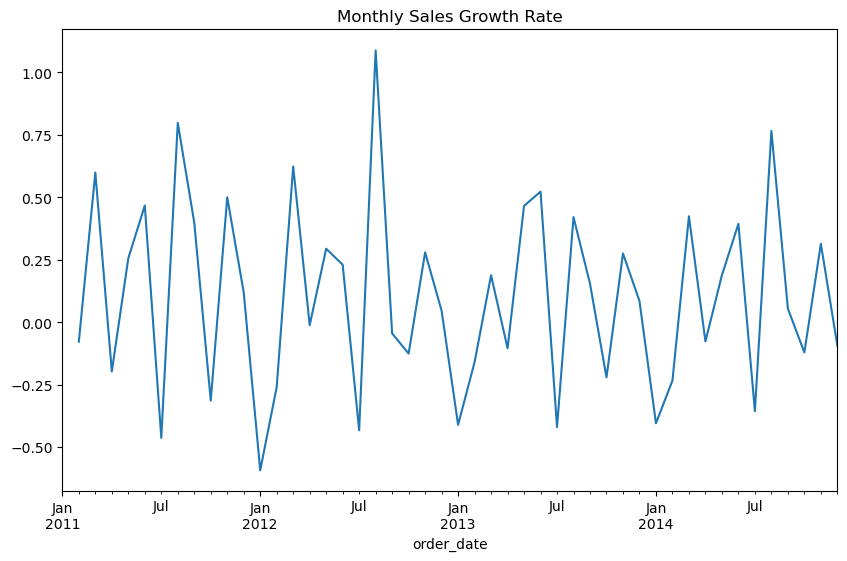

In [39]:
monthly_growth = monthly_sales.pct_change()

plt.figure(figsize=(10,6))
monthly_growth.plot()
plt.title("Monthly Sales Growth Rate")
plt.show()

Insights 2

In contrast to the steady upward secular trend seen in raw sales volume, the growth rate oscillates aggressively around a zero-line baseline, demonstrating an intense pattern of short-term cyclical volatility. The metric reaches its absolute historical maximum in late 2012, skyrocketing past a 1.00 ($100\%$) growth rate, while experiencing severe contractionary valleys—most notably plunging to its absolute lowest trough near -0.60 ($-60\%$) around January 2012. This constant sawtooth pattern of sharp peaks and steep retractions repeating on an annual loop reflects a business heavily impacted by seasonal purchasing behaviors, where periods of explosive expansion are consistently followed by sharp market corrections before stabilizing back toward positive growth.

_______________________________________

Product Intelligence Features

1. Product Revenue

In [40]:
product_sales = ( orders.groupby("product_id")["sales"].sum().reset_index())
product_sales.columns = [ "product_id", "product_total_sales"]
orders = orders.merge(  product_sales,  on="product_id",  how="left")

2. Product Profitability

In [41]:
product_profit = (orders.groupby("product_id")["profit"] .sum()  .reset_index())
product_profit.columns = [  "product_id",  "product_total_profit"]
orders = orders.merge( product_profit, on="product_id",  how="left")

_____________________________________

Regional Intelligence Features

1. Regional Sales

In [42]:
regional_sales = ( orders.groupby("region")["sales"] .sum() .reset_index())
regional_sales.columns = [ "region",  "regional_total_sales"]
orders = orders.merge(  regional_sales,  on="region",  how="left")

_______________________________________________

Anomaly Engineering

1. High Sales Anomaly

In [43]:
sales_threshold = ( orders["sales"] .quantile(0.80))
orders["high_sales_anomaly"] = np.where( orders["sales"] > sales_threshold,   1,  0)

2. Extreme Discount Anomaly 

In [44]:
orders["extreme_discount_flag"] = np.where( orders["discount"] > 0.55, 1,0)

3. Negetive Profit Anomaly

In [45]:
orders["negative_profit_flag"] = np.where( orders["profit"] < 0,1,0)

_________________________

Final Data Validation

In [46]:
orders.isnull().sum()

row_id                        0
order_id                      0
order_date                    0
ship_date                     0
ship_mode                     0
customer_id                   0
customer_name                 0
segment                       0
city                          0
state                         0
country                       0
market                        0
region                        0
product_id                    0
category                      0
sub_category                  0
product_name                  0
sales                         0
quantity                      0
discount                      0
profit                        0
shipping_cost                 0
order_priority                0
order_year                    0
order_month                   0
order_day                     0
order_quarter                 0
order_weekday                 0
is_weekend                    0
shipping_days                 0
shipping_speed             2600
profit_m

In [47]:
orders=orders.dropna()

In [48]:
orders.isnull().sum()

row_id                     0
order_id                   0
order_date                 0
ship_date                  0
ship_mode                  0
customer_id                0
customer_name              0
segment                    0
city                       0
state                      0
country                    0
market                     0
region                     0
product_id                 0
category                   0
sub_category               0
product_name               0
sales                      0
quantity                   0
discount                   0
profit                     0
shipping_cost              0
order_priority             0
order_year                 0
order_month                0
order_day                  0
order_quarter              0
order_weekday              0
is_weekend                 0
shipping_days              0
shipping_speed             0
profit_margin              0
high_discount_flag         0
loss_order_flag            0
total_orders  

In [49]:
orders.to_csv("C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/processed_orders.csv", index=False)

In [51]:
rfm.to_csv( "C:/Users/jsero/OneDrive/Desktop/Analyst Portfolio/Global Sales Enterprise/rfm_dataset.csv", index=False)

Conclusion

This notebook transformed raw transactional retail data into enterprise-grade analytical datasets suitable for advanced analytics and machine learning workflows.

Key accomplishments include:
* data cleaning and validation
* feature engineering
* churn-risk simulation
* customer intelligence creation
* profitability analysis
* anomaly flag engineering
* operational metric generation

The processed datasets produced in this notebook will support:
* SQL warehouse development
* customer segmentation
* forecasting models
* anomaly detection systems
* Power BI dashboards
* executive reporting

This notebook establishes the analytical foundation required for a scalable enterprise retail intelligence platform.